In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
transform = transforms.ToTensor()

train_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 95.8kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 803kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 942kB/s]


In [4]:
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 54000
Val: 6000
Test: 10000


In [6]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 8 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8 x 14 x 14

            nn.Conv2d(8, 16, kernel_size=3, padding=1), # 16 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16 x 7 x 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNIST_CNN().to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

Trainable parameters: 26698


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [9]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}\n")

Epoch 1:
Train Loss: 0.5154, Train Acc: 0.8510
Val Loss: 0.1963, Val Acc: 0.9415

Epoch 2:
Train Loss: 0.1374, Train Acc: 0.9589
Val Loss: 0.1282, Val Acc: 0.9598

Epoch 3:
Train Loss: 0.0963, Train Acc: 0.9707
Val Loss: 0.0904, Val Acc: 0.9728

Epoch 4:
Train Loss: 0.0772, Train Acc: 0.9762
Val Loss: 0.0807, Val Acc: 0.9758

Epoch 5:
Train Loss: 0.0662, Train Acc: 0.9792
Val Loss: 0.0764, Val Acc: 0.9780

Epoch 6:
Train Loss: 0.0585, Train Acc: 0.9819
Val Loss: 0.0662, Val Acc: 0.9807

Epoch 7:
Train Loss: 0.0546, Train Acc: 0.9826
Val Loss: 0.0637, Val Acc: 0.9833

Epoch 8:
Train Loss: 0.0484, Train Acc: 0.9855
Val Loss: 0.0734, Val Acc: 0.9792

Epoch 9:
Train Loss: 0.0457, Train Acc: 0.9853
Val Loss: 0.0602, Val Acc: 0.9832

Epoch 10:
Train Loss: 0.0411, Train Acc: 0.9871
Val Loss: 0.0589, Val Acc: 0.9848



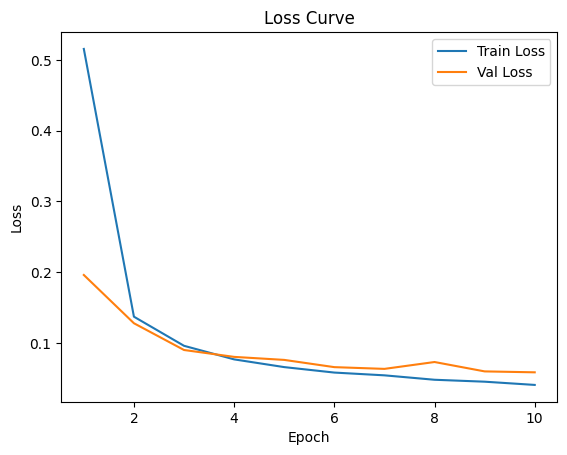

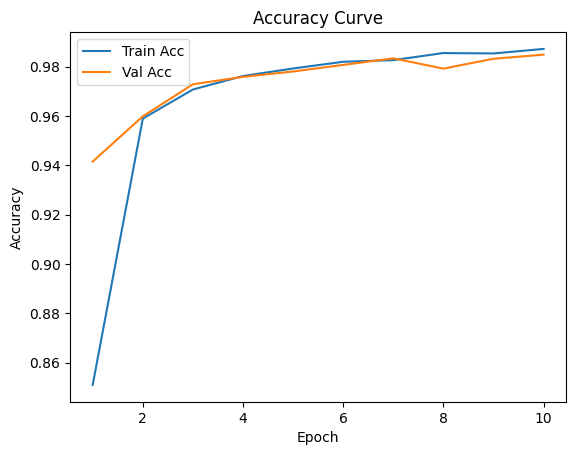

In [10]:
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [11]:
test_loss, test_acc = evaluate(model, test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0427
Test Accuracy: 0.9856


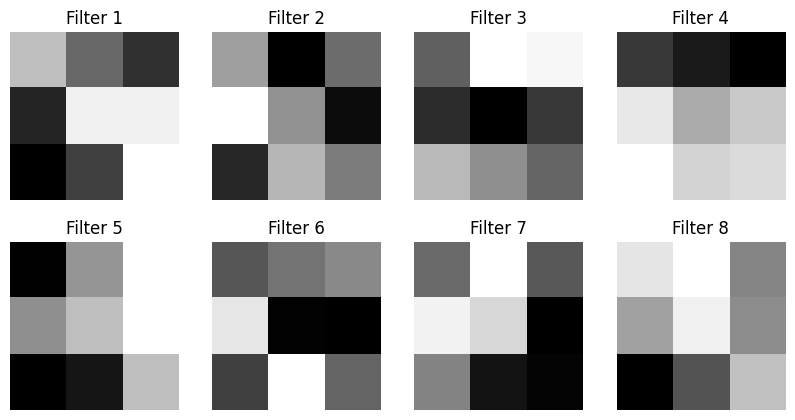

In [12]:
weights = model.features[0].weight.data.cpu()

plt.figure(figsize=(10,5))
for i in range(min(8, weights.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(weights[i,0], cmap='gray')
    plt.title(f"Filter {i+1}")
    plt.axis("off")
plt.show()

In [13]:
test_loss, test_acc = evaluate(model, test_loader)
print(test_acc)

0.9856


In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [15]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [16]:
TRAIN_PATH = "train_biased.pt"
TEST_BIASED_PATH = "test_biased.pt"
TEST_UNBIASED_PATH = "test_unbiased.pt"

for p in [TRAIN_PATH, TEST_BIASED_PATH, TEST_UNBIASED_PATH]:
    print(p, "exists ->", os.path.exists(p))

train_biased.pt exists -> True
test_biased.pt exists -> True
test_unbiased.pt exists -> True


In [17]:
class PTDataset(Dataset):
    def __init__(self, pt_path):
        obj = torch.load(pt_path, map_location="cpu")
        self.images, self.labels = self.parse_obj(obj)

        if not torch.is_tensor(self.images):
            self.images = torch.tensor(self.images)
        if not torch.is_tensor(self.labels):
            self.labels = torch.tensor(self.labels)

        self.images = self.images.float()
        self.labels = self.labels.long()

        # Shape handling
        if self.images.ndim == 3:
            # N,H,W -> N,1,H,W
            self.images = self.images.unsqueeze(1)
        elif self.images.ndim == 4:
            # N,H,W,C -> N,C,H,W
            if self.images.shape[-1] in [1, 3] and self.images.shape[1] not in [1, 3]:
                self.images = self.images.permute(0, 3, 1, 2)

        # Scale to [0,1] if needed
        if self.images.max() > 1.0:
            self.images = self.images / 255.0

        # Make sure 3-channel
        if self.images.shape[1] == 1:
            self.images = self.images.repeat(1, 3, 1, 1)

        assert self.images.ndim == 4, f"Bad image shape: {self.images.shape}"
        assert self.images.shape[1] == 3, f"Expected 3 channels, got {self.images.shape}"
        assert len(self.images) == len(self.labels), "Image-label mismatch"

    def parse_obj(self, obj):
        if isinstance(obj, (tuple, list)) and len(obj) >= 2:
            return obj[0], obj[1]

        if isinstance(obj, dict):
            image_keys = ["images", "x", "data", "X"]
            label_keys = ["labels", "y", "targets", "Y"]

            images = None
            labels = None

            for k in image_keys:
                if k in obj:
                    images = obj[k]
                    break

            for k in label_keys:
                if k in obj:
                    labels = obj[k]
                    break

            if images is not None and labels is not None:
                return images, labels

            print("Available keys:", obj.keys())
            raise ValueError("Could not find image/label keys.")

        if hasattr(obj, "__len__") and hasattr(obj, "__getitem__"):
            images, labels = [], []
            for i in range(len(obj)):
                x, y = obj[i]
                images.append(torch.as_tensor(x))
                labels.append(y)
            return torch.stack(images), torch.tensor(labels)

        raise ValueError(f"Unsupported object type: {type(obj)}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [18]:
full_train_dataset = PTDataset(TRAIN_PATH)
test_biased_dataset = PTDataset(TEST_BIASED_PATH)
test_unbiased_dataset = PTDataset(TEST_UNBIASED_PATH)

print("Train:", full_train_dataset.images.shape, full_train_dataset.labels.shape)
print("Test biased:", test_biased_dataset.images.shape, test_biased_dataset.labels.shape)
print("Test unbiased:", test_unbiased_dataset.images.shape, test_unbiased_dataset.labels.shape)

print("Classes in train:", torch.unique(full_train_dataset.labels))

Train: torch.Size([60000, 3, 28, 28]) torch.Size([60000])
Test biased: torch.Size([10000, 3, 28, 28]) torch.Size([10000])
Test unbiased: torch.Size([10000, 3, 28, 28]) torch.Size([10000])
Classes in train: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


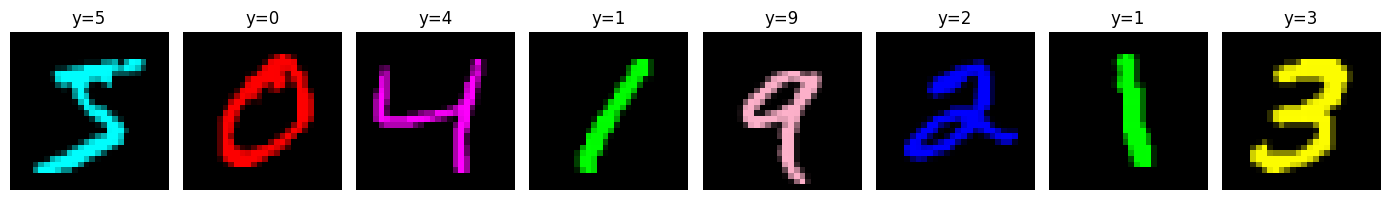

In [19]:
def show_samples(dataset, n=8):
    plt.figure(figsize=(14, 3))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"y={label.item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(full_train_dataset, n=8)

In [20]:
val_ratio = 0.1
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_biased_loader = DataLoader(test_biased_dataset, batch_size=batch_size, shuffle=False)
test_unbiased_loader = DataLoader(test_unbiased_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 54000
Val size: 6000


In [21]:
class ColoredMNISTCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),    # 8 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 8 x 14 x 14

            nn.Conv2d(8, 16, kernel_size=3, padding=1),   # 16 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16 x 7 x 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ColoredMNISTCNN().to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", num_params)

ColoredMNISTCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)
Trainable parameters: 26842


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [23]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_path = "best_colored_mnist_cnn.pt"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
    )

print("Best validation accuracy:", best_val_acc)

Epoch 1: Train Loss=0.5072, Train Acc=0.8584, Val Loss=0.1436, Val Acc=0.9627
Epoch 2: Train Loss=0.1649, Train Acc=0.9568, Val Loss=0.1079, Val Acc=0.9705
Epoch 3: Train Loss=0.1277, Train Acc=0.9649, Val Loss=0.0856, Val Acc=0.9750
Epoch 4: Train Loss=0.1054, Train Acc=0.9708, Val Loss=0.0679, Val Acc=0.9812
Epoch 5: Train Loss=0.0932, Train Acc=0.9736, Val Loss=0.0607, Val Acc=0.9822
Epoch 6: Train Loss=0.0787, Train Acc=0.9768, Val Loss=0.0520, Val Acc=0.9845
Epoch 7: Train Loss=0.0703, Train Acc=0.9794, Val Loss=0.0510, Val Acc=0.9867
Epoch 8: Train Loss=0.0647, Train Acc=0.9807, Val Loss=0.0463, Val Acc=0.9858
Epoch 9: Train Loss=0.0586, Train Acc=0.9825, Val Loss=0.0478, Val Acc=0.9875
Epoch 10: Train Loss=0.0562, Train Acc=0.9833, Val Loss=0.0477, Val Acc=0.9872
Best validation accuracy: 0.9875


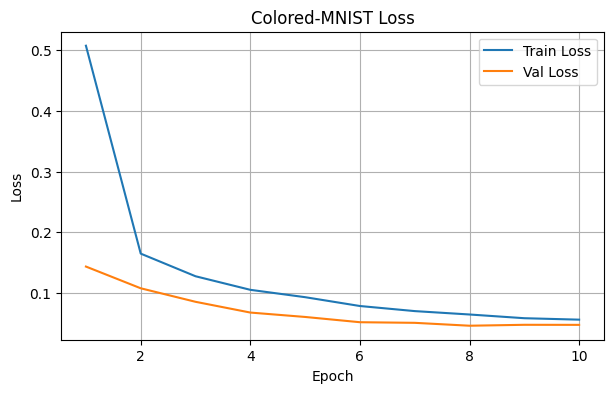

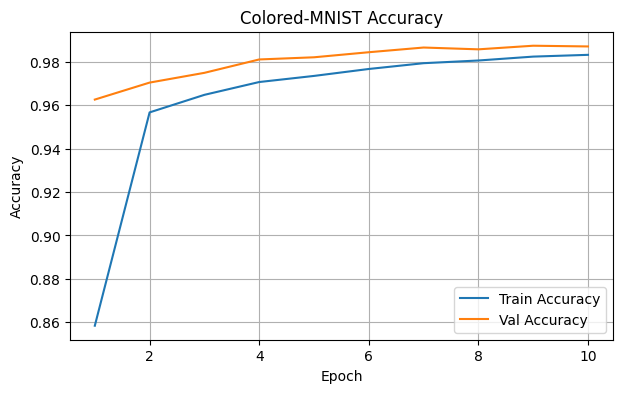

In [24]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Colored-MNIST Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Colored-MNIST Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
best_model = ColoredMNISTCNN().to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_biased_loss, test_biased_acc = evaluate(best_model, test_biased_loader, criterion)
test_unbiased_loss, test_unbiased_acc = evaluate(best_model, test_unbiased_loader, criterion)

print(f"Biased Test Loss: {test_biased_loss:.4f}")
print(f"Biased Test Accuracy: {test_biased_acc:.4f}")

print(f"Unbiased Test Loss: {test_unbiased_loss:.4f}")
print(f"Unbiased Test Accuracy: {test_unbiased_acc:.4f}")

Biased Test Loss: 0.0393
Biased Test Accuracy: 0.9881
Unbiased Test Loss: 0.6199
Unbiased Test Accuracy: 0.8167


In [26]:
torch.save(best_model.state_dict(), "colored_mnist_final_state_dict.pt")
print("Saved model to colored_mnist_final_state_dict.pt")

Saved model to colored_mnist_final_state_dict.pt


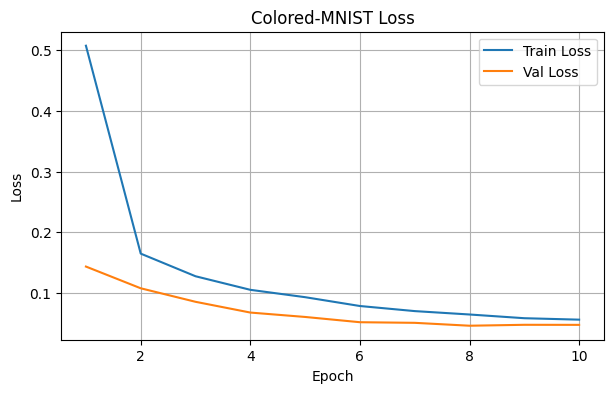

In [27]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Colored-MNIST Loss")
plt.legend()
plt.grid(True)

plt.savefig("colored_mnist_loss.png", dpi=300, bbox_inches='tight')
plt.show()

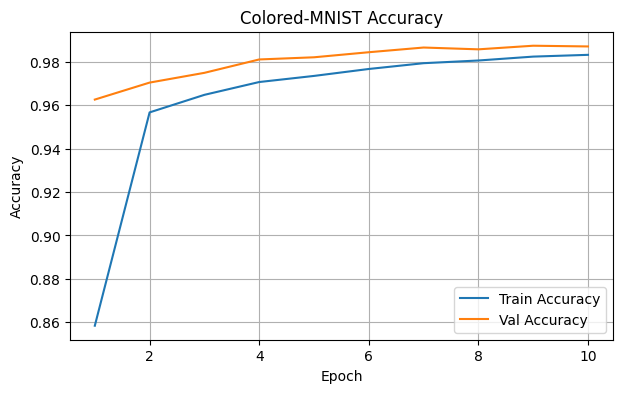

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Colored-MNIST Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("colored_mnist_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

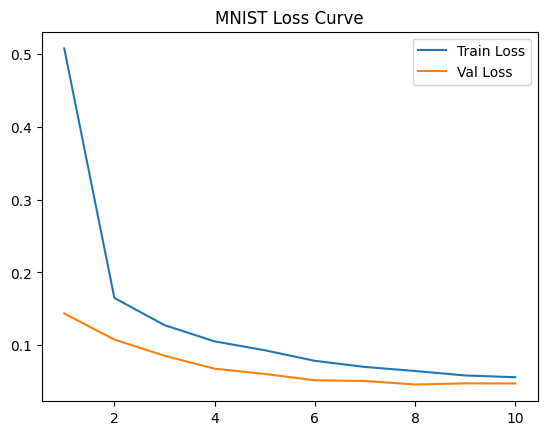

In [29]:
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.legend()
plt.title("MNIST Loss Curve")

plt.savefig("mnist_loss.png", dpi=300, bbox_inches='tight')
plt.show()

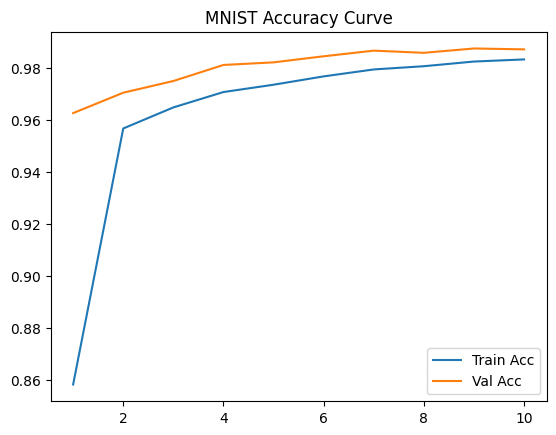

In [30]:
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.legend()
plt.title("MNIST Accuracy Curve")

plt.savefig("mnist_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

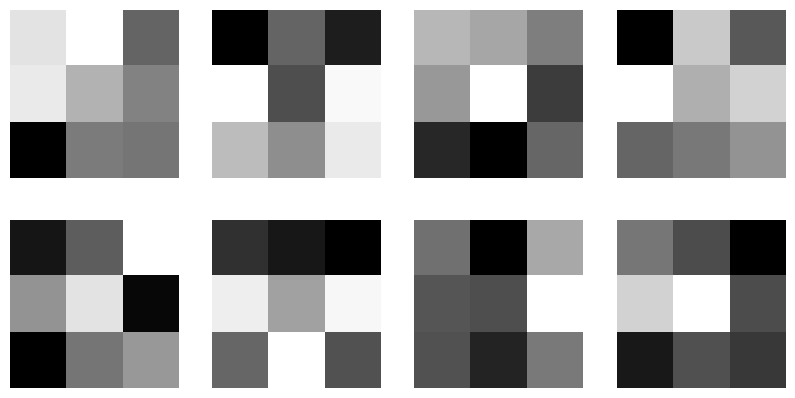

In [31]:
weights = model.features[0].weight.data.cpu()

plt.figure(figsize=(10,5))
for i in range(min(8, weights.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(weights[i,0], cmap='gray')
    plt.axis("off")

plt.savefig("mnist_filters.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
print(model)

ColoredMNISTCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)
